# 直接使用数据

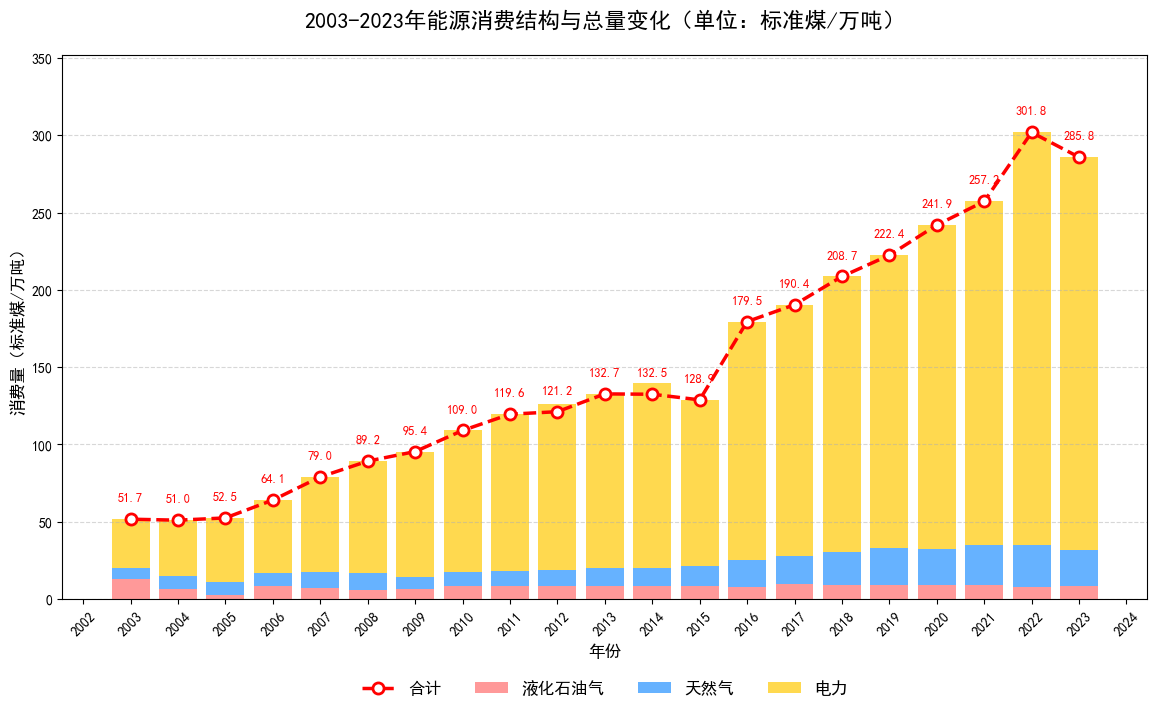

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 数据准备
data = {
    '年份': [2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 
           2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003],
    '合计': [285.82, 301.84, 257.21, 241.93, 222.42, 208.66, 190.37, 179.46, 128.86, 132.49,
            132.72, 121.21, 119.6, 109.05, 95.42, 89.22, 79.02, 64.06, 52.51, 51.04, 51.68],
    '液化石油气': [8.76, 8.01, 9.37, 8.89, 9.18, 8.86, 9.46, 8.07, 8.28, 8.5,
                 8.79, 8.7, 8.43, 8.43, 6.84, 5.96, 7.04, 8.53, 2.66, 6.82, 12.81],
    '天然气': [22.8, 26.68, 25.63, 23.69, 23.85, 21.31, 18.29, 17.3, 13.18, 11.38,
             11.32, 10.11, 9.55, 8.88, 7.75, 11.15, 10.27, 8.54, 8.72, 8.27, 7.3],
    '电力': [254.26, 267.15, 222.21, 209.35, 189.39, 178.49, 162.62, 154.09, 107.4, 119.92,
            112.61, 107.4, 101.62, 91.74, 80.83, 72.11, 61.71, 46.99, 41.13, 35.95, 31.57]
}

# 创建DataFrame
df = pd.DataFrame(data)
df.set_index('年份', inplace=True)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建图表
plt.figure(figsize=(14, 8))

# 绘制堆叠柱状图
colors = ['#FF9999', '#66B2FF', '#ffd94f']  # 调整颜色数量
columns = ['液化石油气', '天然气', '电力']

bottom = None
for i, col in enumerate(columns):
    plt.bar(df.index, df[col], bottom=bottom, label=col, color=colors[i], alpha=1)
    bottom = df[col] if bottom is None else bottom + df[col]

# 绘制合计折线图
line = plt.plot(df.index, df['合计'], 
                marker='o',
                markersize=8,
                markerfacecolor='white',
                markeredgecolor='red',
                markeredgewidth=2,
                color='red',
                linewidth=2.5,
                linestyle='--',
                label='合计')

# 添加数据标签
for year, value in zip(df.index, df['合计']):
    plt.text(year, value + 10, f'{value:.1f}',
             ha='center', va='bottom', 
             fontsize=9, color='red')

# 图表装饰
plt.title('2003-2023年能源消费结构与总量变化（单位：标准煤/万吨）', fontsize=16, pad=20)
plt.xlabel('年份', fontsize=12)
plt.ylabel('消费量（标准煤/万吨）', fontsize=12)

# 调整图例位置和布局
plt.legend(
    loc='upper center',  # 先定位在上方中心
    bbox_to_anchor=(0.5, -0.12),  # 再向下偏移到图表外部
    ncol=4,  # 设置4列（因为有4个图例项）
    frameon=False,  # 去掉图例外框
    fontsize=12
)

# 调整x轴刻度
plt.xticks(df.index, rotation=45)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

# 设置y轴范围
plt.ylim(0, df['合计'].max() + 50)

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 调整布局，为底部图例留出空间
plt.subplots_adjust(bottom=0.2)  # 增加底部边距

# 保存图表
plt.savefig('能源消耗组成结构图.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()

# 从Excel表中读取数据

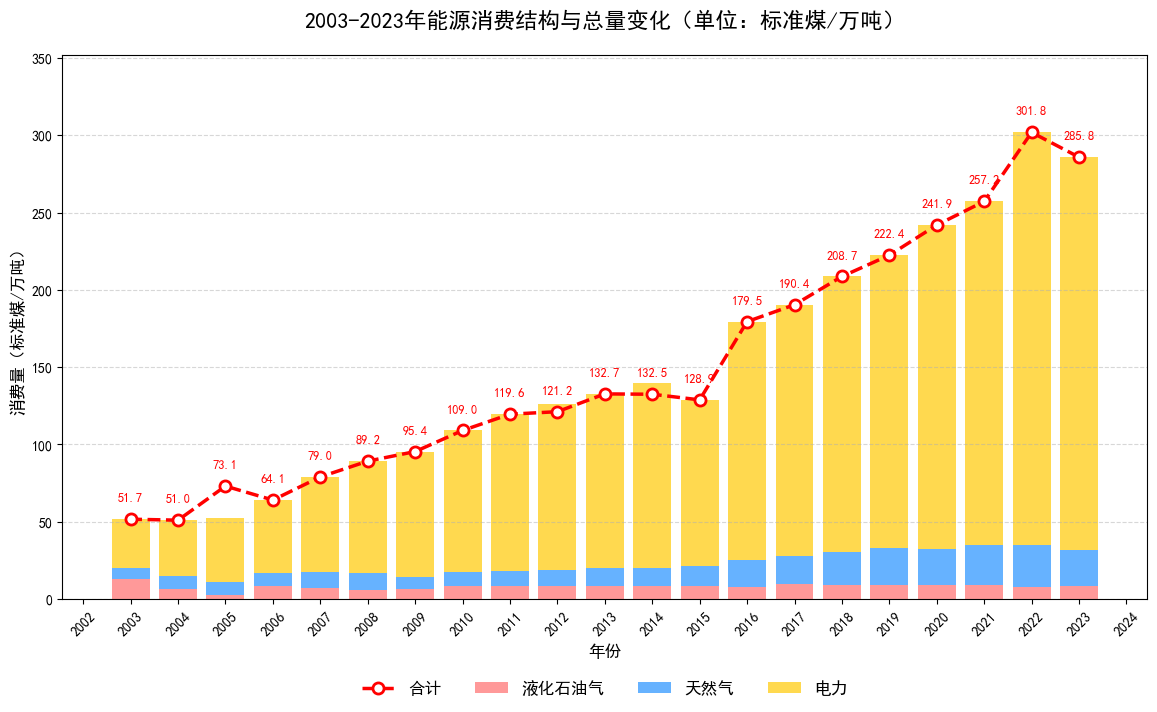

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 数据准备
df = pd.read_excel("能源分类.xlsx")
# 创建DataFrame
df.set_index('年份', inplace=True)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建图表
plt.figure(figsize=(14, 8))

# 绘制堆叠柱状图
colors = ['#FF9999', '#66B2FF', '#ffd94f']  # 调整颜色数量
columns = ['液化石油气', '天然气', '电力']

bottom = None
for i, col in enumerate(columns):
    plt.bar(df.index, df[col], bottom=bottom, label=col, color=colors[i], alpha=1)
    bottom = df[col] if bottom is None else bottom + df[col]

# 绘制合计折线图
line = plt.plot(df.index, df['合计'], 
                marker='o',
                markersize=8,
                markerfacecolor='white',
                markeredgecolor='red',
                markeredgewidth=2,
                color='red',
                linewidth=2.5,
                linestyle='--',
                label='合计')

# 添加数据标签
for year, value in zip(df.index, df['合计']):
    plt.text(year, value + 10, f'{value:.1f}',
             ha='center', va='bottom', 
             fontsize=9, color='red')

# 图表装饰
plt.title('2003-2023年能源消费结构与总量变化（单位：标准煤/万吨）', fontsize=16, pad=20)
plt.xlabel('年份', fontsize=12)
plt.ylabel('消费量（标准煤/万吨）', fontsize=12)

# 调整图例位置和布局
plt.legend(
    loc='upper center',  # 先定位在上方中心
    bbox_to_anchor=(0.5, -0.12),  # 再向下偏移到图表外部
    ncol=4,  # 设置4列（因为有4个图例项）
    frameon=False,  # 去掉图例外框
    fontsize=12
)

# 调整x轴刻度
plt.xticks(df.index, rotation=45)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

# 设置y轴范围
plt.ylim(0, df['合计'].max() + 50)

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 调整布局，为底部图例留出空间
plt.subplots_adjust(bottom=0.2)  # 增加底部边距

# 保存图表
plt.savefig('能源消耗组成结构图.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()